<a href="https://colab.research.google.com/github/angioitoan2409/flood_forecasting/blob/main/02_reservoir_routing_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
BASE_DIR = "/content/drive/MyDrive/flood_forecasting"
MODEL_DIR = f"{BASE_DIR}/model_inputs"
MSD_DIR = f"{BASE_DIR}/val/msd"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##Reservoir routing model

###Import

In [12]:
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import time


###Load static rasters

In [3]:
def load_raster(path):
    with rasterio.open(path) as src:
        return src.read(1), src.nodata

dtm, dtm_nodata = load_raster(f"{MODEL_DIR}/dtm.tif")
buildings, _    = load_raster(f"{MODEL_DIR}/buildings.tif")
sealed, _       = load_raster(f"{MODEL_DIR}/sealed_fraction.tif")
nonsealed, _    = load_raster(f"{MODEL_DIR}/nonsealed_fraction.tif")
ms2_mask        = load_raster(f"{MODEL_DIR}/MS2_mask.tif")[0] == 1
ms5_mask        = load_raster(f"{MODEL_DIR}/MS5_mask.tif")[0] == 1

domain_mask   = dtm != dtm_nodata
building_mask = buildings == 1
ground_mask   = domain_mask & ~building_mask
CELL_AREA_M2  = 25.0

###MSD loader

In [4]:
def load_msd_event(filename):
    df = pd.read_csv(f"{MSD_DIR}/{filename}")
    df["time"] = pd.to_datetime(df["time"])
    df = df.groupby("time", as_index=True).agg(
        lambda s: s.dropna().iloc[0] if s.notna().any() else np.nan
    )
    df_5min = df.resample("5min").mean()
    for col in ["ms2", "ms5", "ms2_before"]:
        df_5min[col + "_m3_per_5min"] = df_5min[col] * 300
    return df_5min

def coverage_adjusted_sum(series):
    coverage = series.notna().mean()
    if coverage == 0:
        return np.nan
    return series.sum() / coverage

EVENTS = ["2017-07-09", "2017-07-10", "2017-07-11", "2019-06-12",
          "2020-08-30", "2021-06-29", "2021-07-13", "2021-07-16"]

FILENAME_TO_EVENT = {
    "2017-07-09.txt": "2017-07-09", "2017-07-10.txt": "2017-07-10",
    "2017-07-11.txt": "2017-07-11", "2019-06-12.txt": "2019-06-12",
    "2020-08.txt": "2020-08-30", "2021-06-30.txt": "2021-06-29",
    "2021-07-13.txt": "2021-07-13", "2021-07-17.txt": "2021-07-16",
}
EVENT_TO_FILENAME = {v: k for k, v in FILENAME_TO_EVENT.items()}


###Baseline capacity model

In [5]:
PARAM_SETS = {
    "run1": dict(infiltration_mm_h=10, sewer_mm_h=20, threshold_mm=5),
    "run2": dict(infiltration_mm_h=10, sewer_mm_h=25, threshold_mm=5),
    "run3": dict(infiltration_mm_h=10, sewer_mm_h=20, threshold_mm=2),
    "run4": dict(infiltration_mm_h=10, sewer_mm_h=25, threshold_mm=2),
}

def run_capacity_model(rain_stack, dt_minutes, params):
    n_t, H, W = rain_stack.shape
    ponding = np.zeros((H, W), dtype=np.float32)

    sewer_cap_per_step = params["sewer_mm_h"] * dt_minutes / 60.0 * sealed
    infil_cap_per_step = params["infiltration_mm_h"] * dt_minutes / 60.0 * nonsealed
    threshold = params["threshold_mm"]

    ms2_series = np.zeros(n_t)
    ms5_series = np.zeros(n_t)

    for t in range(n_t):
        rain_t = rain_stack[t]
        roof_drained = np.where(building_mask, rain_t, 0.0)
        ponding[ground_mask] += rain_t[ground_mask]

        active = ponding > threshold
        sewer_drained = np.where(active & ground_mask,
                                  np.minimum(sewer_cap_per_step, ponding), 0.0)
        remaining = ponding - sewer_drained
        infil_drained = np.where(ground_mask,
                                  np.minimum(infil_cap_per_step, np.maximum(remaining, 0)), 0.0)
        ponding = np.maximum(ponding - sewer_drained - infil_drained, 0.0)

        roof_vol  = roof_drained  * CELL_AREA_M2 / 1000.0
        sewer_vol = sewer_drained * CELL_AREA_M2 / 1000.0
        total_drain = roof_vol + sewer_vol

        ms2_series[t] = total_drain[ms2_mask].sum()
        ms5_series[t] = total_drain[ms5_mask].sum()

    return dict(ms2_total=ms2_series, ms5_total=ms5_series)


Run baseline model with lag + reservoir routing

In [8]:
def route_lag_and_reservoir(series, lag_minutes, k_minutes, dt_minutes=5):
    lag_steps = int(round(lag_minutes / dt_minutes))
    shifted = np.concatenate([np.zeros(lag_steps), series])
    k_steps = max(k_minutes / dt_minutes, 1e-6)
    S = 0.0
    outflow = np.zeros_like(shifted, dtype=np.float64)
    for i, inflow in enumerate(shifted):
        S += inflow - S / k_steps
        outflow[i] = S / k_steps
    return outflow

def run_padded_and_routed(event, params, lag_minutes, k_minutes, cooldown_multiplier=5, dt_minutes=5):
    d = np.load(f"{MODEL_DIR}/radolan_aligned/{event}_aligned.npz", allow_pickle=True)
    rain_stack = d["rain_mm"]
    rain_ts = pd.to_datetime(d["timestamps"])

    lag_steps = int(round(lag_minutes / dt_minutes))
    n_cooldown_steps = int(np.ceil(k_minutes * cooldown_multiplier / dt_minutes))

    H, W = rain_stack.shape[1:]
    padding = np.zeros((n_cooldown_steps, H, W), dtype=rain_stack.dtype)
    rain_padded = np.concatenate([rain_stack, padding], axis=0)

    result = run_capacity_model(rain_padded, dt_minutes=dt_minutes, params=params)

    routed_ms2 = route_lag_and_reservoir(result["ms2_total"], lag_minutes, k_minutes, dt_minutes)
    routed_ms5 = route_lag_and_reservoir(result["ms5_total"], lag_minutes, k_minutes, dt_minutes)

    # raw series timestamps (shorter, no lag applied)
    extra_ts_raw = pd.date_range(start=rain_ts[-1] + pd.Timedelta(minutes=dt_minutes),
                                  periods=n_cooldown_steps, freq=f"{dt_minutes}min")
    ts_raw = rain_ts.append(extra_ts_raw)

    # routed series timestamps (longer, includes the lag shift)
    extra_ts_routed = pd.date_range(start=rain_ts[-1] + pd.Timedelta(minutes=dt_minutes),
                                     periods=n_cooldown_steps + lag_steps, freq=f"{dt_minutes}min")
    ts_routed = rain_ts.append(extra_ts_routed)

    return dict(ts_raw=ts_raw, ts_routed=ts_routed,
                ms2_raw=result["ms2_total"], ms5_raw=result["ms5_total"],
                ms2_routed=routed_ms2, ms5_routed=routed_ms5)


##Test

###Test on 2017-07-09, lag=65min, k=30min

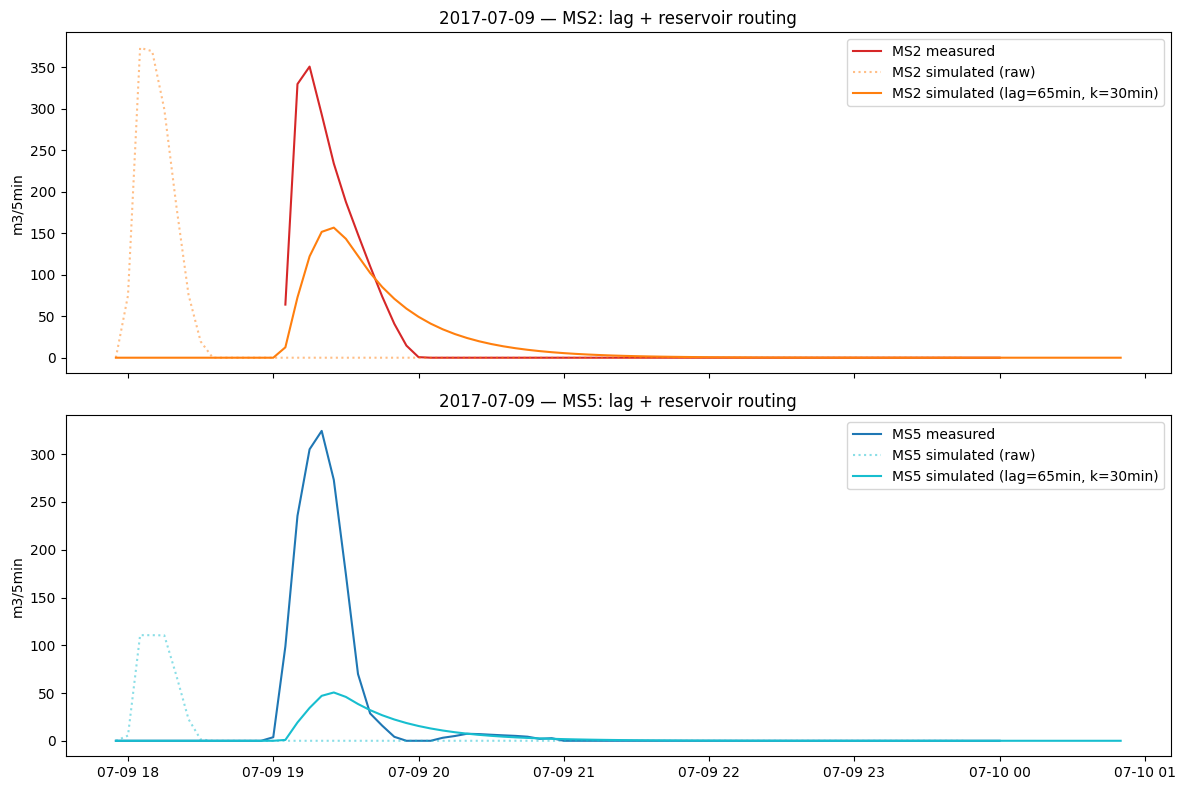

In [9]:
test_event = "2017-07-09"
LAG_MINUTES = 65
K_MINUTES = 30

routed_result = run_padded_and_routed(test_event, PARAM_SETS["run1"],
                                       lag_minutes=LAG_MINUTES, k_minutes=K_MINUTES)

msd = load_msd_event(EVENT_TO_FILENAME[test_event])
msd_window = msd.loc[routed_result["ts_routed"].min():routed_result["ts_routed"].max()]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(msd_window.index, msd_window["ms2_m3_per_5min"], color="tab:red", label="MS2 measured")
axes[0].plot(routed_result["ts_raw"], routed_result["ms2_raw"], color="tab:orange",
             linestyle=":", alpha=0.5, label="MS2 simulated (raw)")
axes[0].plot(routed_result["ts_routed"], routed_result["ms2_routed"], color="tab:orange",
             linestyle="-", label=f"MS2 simulated (lag={LAG_MINUTES}min, k={K_MINUTES}min)")
axes[0].legend()
axes[0].set_ylabel("m3/5min")
axes[0].set_title(f"{test_event} — MS2: lag + reservoir routing")

axes[1].plot(msd_window.index, msd_window["ms5_m3_per_5min"], color="tab:blue", label="MS5 measured")
axes[1].plot(routed_result["ts_raw"], routed_result["ms5_raw"], color="tab:cyan",
             linestyle=":", alpha=0.5, label="MS5 simulated (raw)")
axes[1].plot(routed_result["ts_routed"], routed_result["ms5_routed"], color="tab:cyan",
             linestyle="-", label=f"MS5 simulated (lag={LAG_MINUTES}min, k={K_MINUTES}min)")
axes[1].legend()
axes[1].set_ylabel("m3/5min")
axes[1].set_title(f"{test_event} — MS5: lag + reservoir routing")

plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/../routing_test_{test_event}_v2.png", dpi=120)
plt.show()

  Based on the lag on the MSD files. 7/8 events cluster tightly in the 65-90 min range. I decided to choose fixed lag = 75.

###Fixed lag/k sweep across all 8 events

In [10]:
LAG_MINUTES_FIXED = 75  # from the physical rain-to-discharge lag cluster, not fit to any single event

routing_results = []

for event in EVENTS:
    routed_by_k = {}
    for k in [5, 10, 15]:
        r = run_padded_and_routed(event, PARAM_SETS["run1"],
                                   lag_minutes=LAG_MINUTES_FIXED, k_minutes=k)
        routed_by_k[k] = r

    msd = load_msd_event(EVENT_TO_FILENAME[event])
    ts_routed = routed_by_k[5]["ts_routed"]  # same length regardless of k, since lag is fixed
    msd_window = msd.loc[ts_routed.min():ts_routed.max()]

    measured_ms2_peak = msd_window["ms2_m3_per_5min"].max()
    measured_ms2_peak_time = msd_window["ms2_m3_per_5min"].idxmax()
    measured_ms5_peak = msd_window["ms5_m3_per_5min"].max()
    measured_ms5_peak_time = msd_window["ms5_m3_per_5min"].idxmax()

    for k, r in routed_by_k.items():
        sim_ms2_peak = r["ms2_routed"].max()
        sim_ms2_peak_time = r["ts_routed"][r["ms2_routed"].argmax()]
        sim_ms5_peak = r["ms5_routed"].max()
        sim_ms5_peak_time = r["ts_routed"][r["ms5_routed"].argmax()]

        ms2_peak_err_pct = 100 * (sim_ms2_peak - measured_ms2_peak) / measured_ms2_peak if measured_ms2_peak > 0 else np.nan
        ms5_peak_err_pct = 100 * (sim_ms5_peak - measured_ms5_peak) / measured_ms5_peak if measured_ms5_peak > 0 else np.nan
        ms2_time_err_min = (sim_ms2_peak_time - measured_ms2_peak_time).total_seconds() / 60
        ms5_time_err_min = (sim_ms5_peak_time - measured_ms5_peak_time).total_seconds() / 60

        routing_results.append({
            "event": event, "k": k,
            "MS2_peak_err_%": ms2_peak_err_pct, "MS2_time_err_min": ms2_time_err_min,
            "MS5_peak_err_%": ms5_peak_err_pct, "MS5_time_err_min": ms5_time_err_min,
        })

    print(f"{event} done")

df_routing = pd.DataFrame(routing_results)
pd.set_option("display.width", 150)
print(df_routing.round(1))

print("\n=== Summary across all 8 events, per k (lag fixed at 75min) ===")
summary_routing = df_routing.groupby("k")[
    ["MS2_peak_err_%", "MS2_time_err_min", "MS5_peak_err_%", "MS5_time_err_min"]
].agg(["mean", "std"])
print(summary_routing.round(1))

2017-07-09 done
2017-07-10 done
2017-07-11 done
2019-06-12 done
2020-08-30 done
2021-06-29 done
2021-07-13 done
2021-07-16 done
         event   k  MS2_peak_err_%  MS2_time_err_min  MS5_peak_err_%  MS5_time_err_min
0   2017-07-09   5             6.4               5.0           -65.9               0.0
1   2017-07-09  10           -16.4              15.0           -70.1              10.0
2   2017-07-09  15           -30.3              15.0           -75.9              10.0
3   2017-07-10   5           320.9               5.0           -13.4              15.0
4   2017-07-10  10           169.0              10.0           -45.2              20.0
5   2017-07-10  15           103.1              10.0           -58.4              20.0
6   2017-07-11   5           -28.0               5.0           -93.8              25.0
7   2017-07-11  10           -47.0              15.0           -95.8              25.0
8   2017-07-11  15           -55.8              15.0           -96.9              25.0
9 

###Visualize

2017-07-09 done
2017-07-10 done
2017-07-11 done
2019-06-12 done
2020-08-30 done
2021-06-29 done
2021-07-13 done
2021-07-16 done


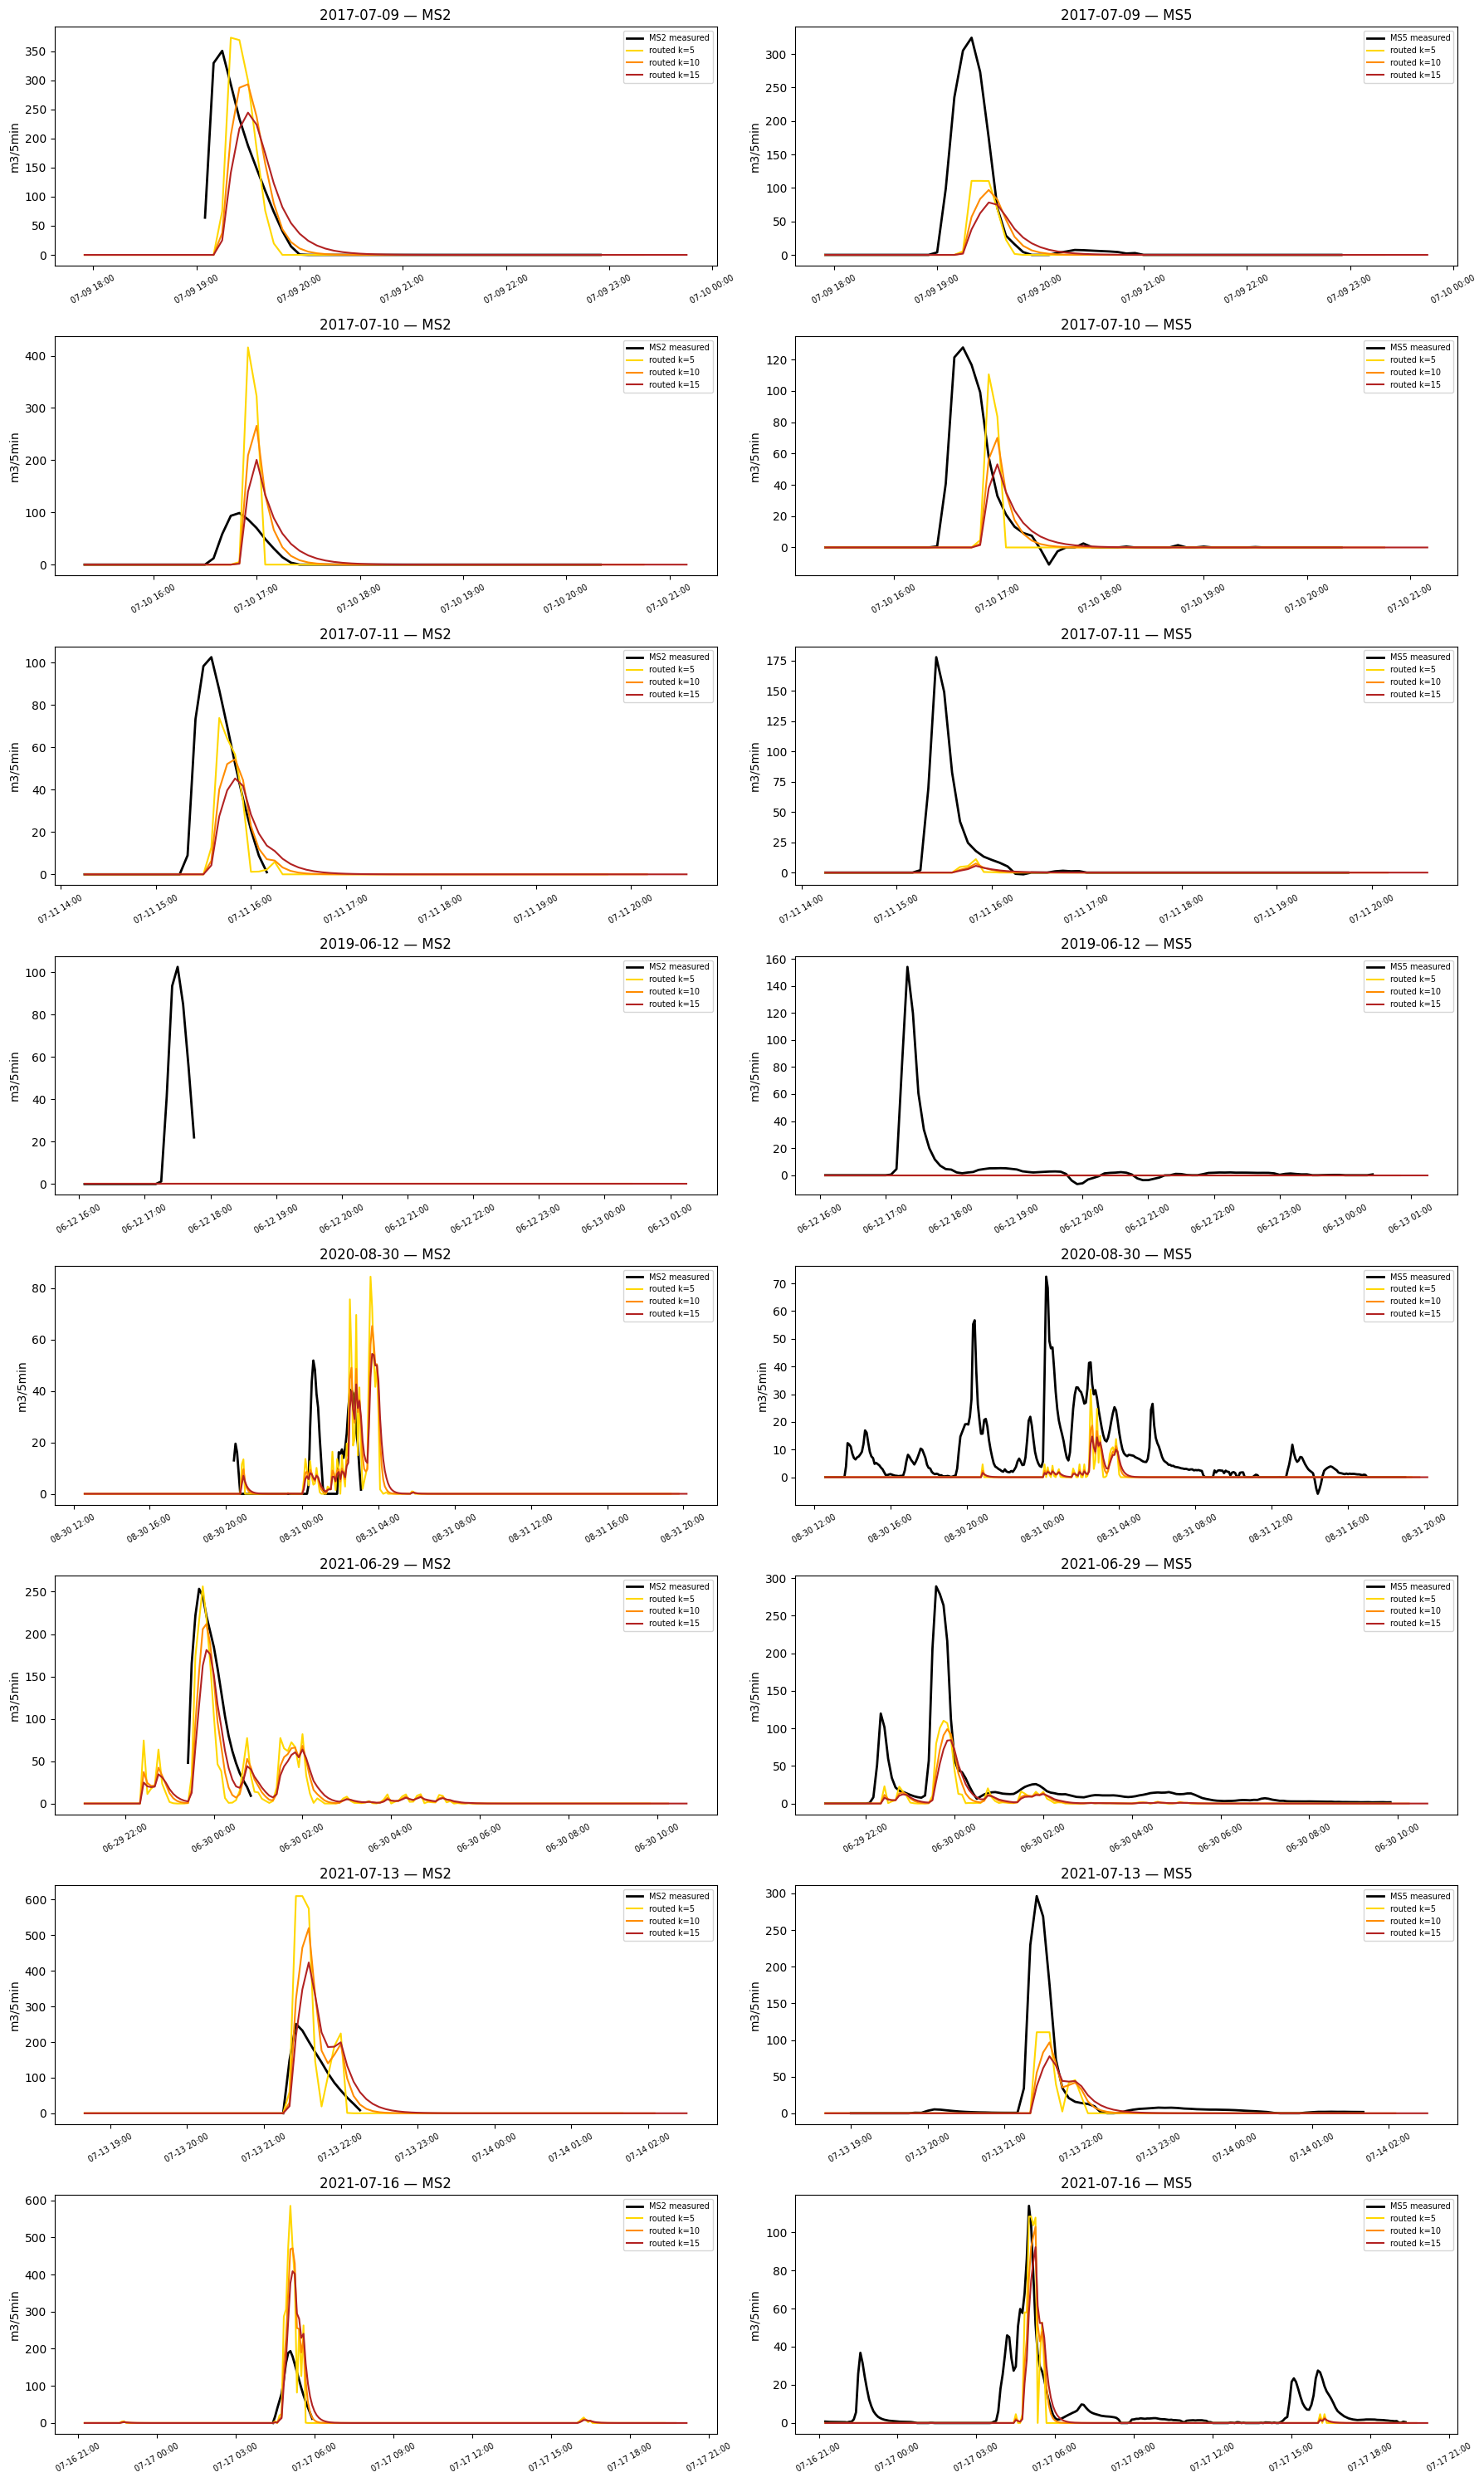

In [13]:
LAG_MINUTES_FIXED = 75
K_VALUES = [5, 10, 15]
K_COLORS = {5: "gold", 10: "darkorange", 15: "firebrick"}

event_routing_results = {}

for event in EVENTS:
    runs_by_k = {}
    for k in K_VALUES:
        runs_by_k[k] = run_padded_and_routed(event, PARAM_SETS["run1"],
                                              lag_minutes=LAG_MINUTES_FIXED, k_minutes=k)
    msd = load_msd_event(EVENT_TO_FILENAME[event])
    ts_ref = runs_by_k[K_VALUES[0]]["ts_routed"]
    msd_window = msd.loc[ts_ref.min():ts_ref.max()]
    event_routing_results[event] = dict(runs_by_k=runs_by_k, msd_window=msd_window)
    print(f"{event} done")

fig, axes = plt.subplots(8, 2, figsize=(18, 30))

for i, event in enumerate(EVENTS):
    runs_by_k = event_routing_results[event]["runs_by_k"]
    msd_window = event_routing_results[event]["msd_window"]

    # --- MS2 ---
    ax = axes[i, 0]
    ax.plot(msd_window.index, msd_window["ms2_m3_per_5min"], color="black", linewidth=2, label="MS2 measured")
    for k in K_VALUES:
        r = runs_by_k[k]
        ax.plot(r["ts_routed"], r["ms2_routed"], color=K_COLORS[k], linestyle="-", label=f"routed k={k}")
    ax.set_title(f"{event} — MS2")
    ax.legend(fontsize=7)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.set_ylabel("m3/5min")

    # --- MS5 ---
    ax = axes[i, 1]
    ax.plot(msd_window.index, msd_window["ms5_m3_per_5min"], color="black", linewidth=2, label="MS5 measured")
    for k in K_VALUES:
        r = runs_by_k[k]
        ax.plot(r["ts_routed"], r["ms5_routed"], color=K_COLORS[k], linestyle="-", label=f"routed k={k}")
    ax.set_title(f"{event} — MS5")
    ax.legend(fontsize=7)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.set_ylabel("m3/5min")

plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/../routed_model_all_k_all_events.png", dpi=120)
plt.show()

Overall, the summary and the plots show better result than the 01_model. The MS2 and MS5 number on 2019-06-12 event still nothing. I will keep it like this right now and will try to fix it in the next model.